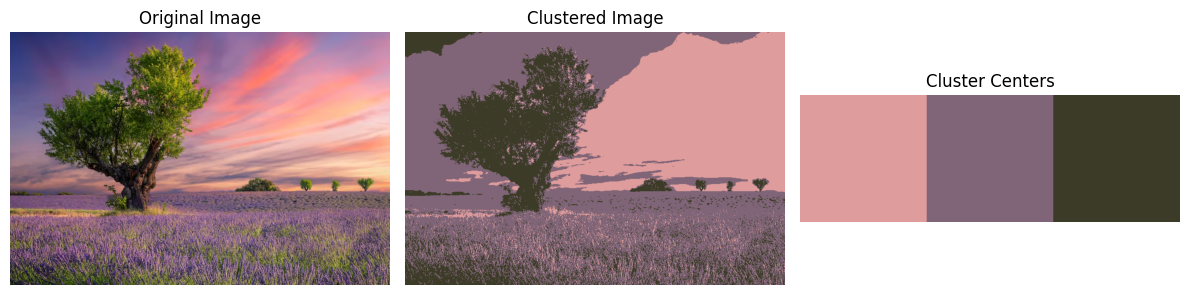

Cluster Centers (RGB values):
Cluster 1 : [223 156 156]
Cluster 2 : [127 101 119]
Cluster 3 : [60 59 39]


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert image to 2D array of pixels
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Number of clusters
k = 3

# Apply K-means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
ret, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert centers to integer
centers = np.uint8(centers)

# Create clustered image
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img.shape)

# Plot original and clustered image
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(segmented_image)
plt.title("Clustered Image")
plt.axis("off")

# Plot cluster centers as color patches
patch = np.zeros((100, 100 * k, 3), dtype=np.uint8)

for i in range(k):
    patch[:, i*100:(i+1)*100] = centers[i]

plt.subplot(1,3,3)
plt.imshow(patch)
plt.title("Cluster Centers")
plt.axis("off")

plt.tight_layout()
plt.show()

# Print center values also
print("Cluster Centers (RGB values):")
for i, c in enumerate(centers):
    print("Cluster", i+1, ":", c)